# eGFR Data Explorer

This notebook allows you to explore data for a specific case number from the DuckDB database.

## Available Tables (Bronze Schema):

### 31-08-2025 Data:
- `bronze.egfr_data` - eGFR measurements and patient information
- `bronze.arterial_segmentation` - Arterial phase segmentation data
- `bronze.late_segmentation` - Late phase segmentation data
- `bronze.venous_segmentation` - Venous phase segmentation data

### 25-11-2025 Data:
- `bronze.anon_egfr` - Anonymized eGFR data
- `bronze.anon_segmentations` - Anonymized segmentation data

In [47]:
import duckdb
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# Set pandas display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)

## Load All Data from Database

Load all tables from the bronze schema into pandas DataFrames.

In [48]:
# Connect to the database
db_path = Path('../database/egfr_data.duckdb')
conn = duckdb.connect(str(db_path), read_only=True)

print(f"Connected to database: {db_path}")
print(f"Loading all tables from bronze schema...\n")

# Load 31-08-2025 tables from bronze schema
egfr_df = conn.execute('SELECT * FROM bronze.egfr_data').df()
arterial_df = conn.execute('SELECT * FROM bronze.arterial_segmentation').df()
late_df = conn.execute('SELECT * FROM bronze.late_segmentation').df()
venous_df = conn.execute('SELECT * FROM bronze.venous_segmentation').df()

# Load 25-11-2025 tables from bronze schema
anon_egfr_df = conn.execute('SELECT * FROM bronze.anon_egfr').df()
anon_seg_df = conn.execute('SELECT * FROM bronze.anon_segmentations').df()

# Load gold tables
seg_df = conn.execute('Select * FROM gold.segmentations').df()


# Load the gold table
anon_seg_egfr_df = conn.execute('SELECT * FROM gold.anon_segmentations_with_egfr').df()


# Close connection - we don't need it anymore
conn.close()

print(f"Loaded tables:")
print(f"\n31-08-2025 Data:")
print(f"  - bronze.egfr_data: {len(egfr_df)} rows")
print(f"  - bronze.arterial_segmentation: {len(arterial_df)} rows")
print(f"  - bronze.late_segmentation: {len(late_df)} rows")
print(f"  - bronze.venous_segmentation: {len(venous_df)} rows")
print(f"\n25-11-2025 Data:")
print(f"  - bronze.anon_egfr: {len(anon_egfr_df)} rows")
print(f"  - bronze.anon_segmentations: {len(anon_seg_df)} rows")
print(f"\nAvailable cases (31-08-2025): {sorted(egfr_df['case_number'].unique(), key=int)}")
print(f"\nSegmentations: {sorted(seg_df['case_number'].unique(), key=int)}")



Connected to database: ..\database\egfr_data.duckdb
Loading all tables from bronze schema...

Loaded tables:

31-08-2025 Data:
  - bronze.egfr_data: 1066 rows
  - bronze.arterial_segmentation: 105 rows
  - bronze.late_segmentation: 115 rows
  - bronze.venous_segmentation: 110 rows

25-11-2025 Data:
  - bronze.anon_egfr: 1064 rows
  - bronze.anon_segmentations: 25 rows

Available cases (31-08-2025): ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25']

Segmentations: ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25']


## Set Case Number

Change the case number below to explore different cases.

In [49]:
# Set the case number you want to explore
case_test = '3'  # Change this to explore different cases

## eGFR Data (31-08-2025)

Patient information and eGFR measurements for the selected case.

In [50]:
# Filter eGFR data for the case
case_egfr = egfr_df[egfr_df['case_number'] == case_test]

case_egfr = case_egfr.dropna(axis=1, how='all')


print(f"eGFR Data for Case {case_test}")
print(f"Number of records: {len(case_egfr)}")
print("\n" + "="*80)

# Display the data
case_egfr

eGFR Data for Case 3
Number of records: 12



,record_id,redcap_repeat_instrument,redcap_repeat_instance,gfr_date,gfr_type,gfr_value,serum_creatinine,gfr_complete,filename,case_number
891,3,gfr,1,03-01-2017,1,>90,57.0,2,eGFR_3.csv,3
892,3,gfr,2,08-05-2017,1,>90,74.0,2,eGFR_3.csv,3
893,3,gfr,3,27-06-2017,1,>90,74.0,2,eGFR_3.csv,3
894,3,gfr,4,08-03-2018,1,>90,83.0,2,eGFR_3.csv,3
895,3,gfr,5,06-01-2019,1,>90,83.0,2,eGFR_3.csv,3
896,3,gfr,6,08-09-2020,1,>90,77.0,2,eGFR_3.csv,3
897,3,gfr,7,19-11-2020,1,>90,66.0,2,eGFR_3.csv,3
898,3,gfr,8,28-06-2022,1,84,88.0,2,eGFR_3.csv,3
899,3,gfr,9,25-09-2024,1,>90,67.0,2,eGFR_3.csv,3
900,3,gfr,10,31-10-2024,1,>90,65.0,2,eGFR_3.csv,3


### Key eGFR Measurements

In [51]:
# Display key columns if they exist
key_columns = ['gfr_date', 'gfr_value', 'serum_creatinine', 'case_number', 'filename']
available_key_cols = [col for col in key_columns if col in case_egfr.columns]

if available_key_cols and len(case_egfr) > 0:
    print(f"Key measurements for Case {case_test}:")
    display(case_egfr[available_key_cols])
else:
    print("No data found for this case")

Key measurements for Case 3:


,gfr_date,gfr_value,serum_creatinine,case_number,filename
891,03-01-2017,>90,57.0,3,eGFR_3.csv
892,08-05-2017,>90,74.0,3,eGFR_3.csv
893,27-06-2017,>90,74.0,3,eGFR_3.csv
894,08-03-2018,>90,83.0,3,eGFR_3.csv
895,06-01-2019,>90,83.0,3,eGFR_3.csv
896,08-09-2020,>90,77.0,3,eGFR_3.csv
897,19-11-2020,>90,66.0,3,eGFR_3.csv
898,28-06-2022,84,88.0,3,eGFR_3.csv
899,25-09-2024,>90,67.0,3,eGFR_3.csv
900,31-10-2024,>90,65.0,3,eGFR_3.csv


## Arterial Segmentation Data

Arterial phase segmentation measurements for the selected case.

In [52]:
# Filter arterial segmentation data
case_arterial = arterial_df[arterial_df['case_number'] == case_test]

print(f"Arterial Segmentation Data for Case {case_test}")
print(f"Number of segments: {len(case_arterial)}")
if len(case_arterial) > 0 and 'Segment' in case_arterial.columns:
    print(f"Segments: {list(case_arterial['Segment'])}")
print("\n" + "="*80)

# Display the data
case_arterial

Arterial Segmentation Data for Case 3
Number of segments: 5
Segments: ['arterial_threshold_3', 'arterial_renal_artery_right_3', 'arterial_renal_artery_left_3', 'arterial_renal_vein_right_3', 'arterial_renal_vein_left_3']



,Segment,Voxel count (LM),Volume mm3 (LM),Volume cm3 (LM),Voxel count (SV),Volume mm3 (SV),Volume cm3 (SV),Minimum,Maximum,Mean,Standard deviation,Percentile 5,Percentile 95,Median,filename,case_number,table_type
85,arterial_threshold_3,1544117,1048210.00,1048.21000,1544117,1048210.00,1048.21000,173,981,283.903,101.1590,180,508,256,table_arterial_3.csv,3,arterial
86,arterial_renal_artery_right_3,1715,1164.21,1.16421,1715,1164.21,1.16421,173,335,244.731,38.7353,180,300,247,table_arterial_3.csv,3,arterial
87,arterial_renal_artery_left_3,1597,1084.11,1.08411,1597,1084.11,1.08411,173,355,250.023,39.4441,181,310,255,table_arterial_3.csv,3,arterial
88,arterial_renal_vein_right_3,1640,1113.30,1.11330,1640,1113.30,1.11330,173,295,243.729,23.1916,191,271,248,table_arterial_3.csv,3,arterial
89,arterial_renal_vein_left_3,4770,3238.07,3.23807,4770,3238.07,3.23807,173,308,243.719,23.8056,191,274,248,table_arterial_3.csv,3,arterial


## Late Segmentation Data

Late phase segmentation measurements for the selected case.

In [53]:
# Filter late segmentation data
case_late = late_df[late_df['case_number'] == case_test]

print(f"Late Segmentation Data for Case {case_test}")
print(f"Number of segments: {len(case_late)}")
if len(case_late) > 0 and 'Segment' in case_late.columns:
    print(f"Segments: {list(case_late['Segment'])}")
print("\n" + "="*80)

# Display the data
case_late

Late Segmentation Data for Case 3
Number of segments: 5
Segments: ['late_threshold_3', 'late_renal_artery_right_3', 'late_renal_artery_left_3', 'late_renal_vein_right_3', 'late_renal_vein_left_3']



,Segment,Voxel count (LM),Volume mm3 (LM),Volume cm3 (LM),Voxel count (SV),Volume mm3 (SV),Volume cm3 (SV),Minimum,Maximum,Mean,Standard deviation,Percentile 5,Percentile 95,Median,filename,case_number,table_type
85,late_threshold_3,4818231,3270810.00,3270.81000,4818231,3270810.00,3270.81000,28,981,97.5205,112.0250,28,346,50,table_late_3.csv,3,late
86,late_renal_artery_right_3,1793,1217.16,1.21716,1793,1217.16,1.21716,28,122,52.9955,17.4200,29,85,49,table_late_3.csv,3,late
87,late_renal_artery_left_3,1984,1346.82,1.34682,1984,1346.82,1.34682,28,128,57.4259,17.4288,30,87,55,table_late_3.csv,3,late
88,late_renal_vein_right_3,1665,1130.27,1.13027,1665,1130.27,1.13027,28,97,53.5315,13.5851,31,75,52,table_late_3.csv,3,late
89,late_renal_vein_left_3,5382,3653.52,3.65352,5382,3653.52,3.65352,28,120,62.4026,17.5732,32,90,62,table_late_3.csv,3,late


## Venous Segmentation Data

Venous phase segmentation measurements for the selected case.

In [54]:
# Filter venous segmentation data
case_venous = venous_df[venous_df['case_number'] == case_test]

print(f"Venous Segmentation Data for Case {case_test}")
print(f"Number of segments: {len(case_venous)}")
if len(case_venous) > 0 and 'Segment' in case_venous.columns:
    print(f"Segments: {list(case_venous['Segment'])}")
print("\n" + "="*80)

# Display the data
case_venous

Venous Segmentation Data for Case 3
Number of segments: 5
Segments: ['venous_threshold_3', 'venous_renal_artery_right_3', 'venous_renal_artery_left_3', 'venous_renal_vein_right_3', 'venous_renal_vein_left_3']



,Segment,Voxel count (LM),Volume mm3 (LM),Volume cm3 (LM),Voxel count (SV),Volume mm3 (SV),Volume cm3 (SV),Minimum,Maximum,Mean,Standard deviation,Percentile 5,Percentile 95,Median,filename,case_number,table_type
75,venous_threshold_3,3282836,2795200.000,2795.200000,3282836,2795200.000,2795.200000,108,981,240.381,136.9520,115,540,187,table_venous_3.csv,3,venous
76,venous_renal_artery_right_3,915,779.086,0.779086,915,779.086,0.779086,108,183,133.383,16.7119,109,161,131,table_venous_3.csv,3,venous
77,venous_renal_artery_left_3,913,777.383,0.777383,913,777.383,0.777383,108,206,136.653,21.0364,109,176,132,table_venous_3.csv,3,venous
78,venous_renal_vein_right_3,1054,897.439,0.897439,1054,897.439,0.897439,108,189,138.340,13.8400,115,160,137,table_venous_3.csv,3,venous
79,venous_renal_vein_left_3,3193,2718.710,2.718710,3193,2718.710,2.718710,108,193,136.091,14.9250,111,161,135,table_venous_3.csv,3,venous


## Anonymized eGFR Data (25-11-2025)

Anonymized eGFR data from the 25-11-2025 dataset.

In [55]:
# Display anonymized eGFR data

anon_egfr_df = anon_egfr_df[anon_egfr_df['record_id'] == int(case_test)]

print(f"Anonymized eGFR Data (25-11-2025)")
print(f"Total records: {len(anon_egfr_df)}")
print(f"Columns: {list(anon_egfr_df.columns)}")
print("\n" + "="*80)

# Display the data
anon_egfr_df

Anonymized eGFR Data (25-11-2025)
Total records: 12
Columns: ['record_id', 'redcap_repeat_instance', 'egfr_date', 'egfr_value', 'serum_creatinine']



,record_id,redcap_repeat_instance,egfr_date,egfr_value,serum_creatinine
1052,3,1,03-01-2017,>90,57.0
1053,3,2,08-05-2017,>90,74.0
1054,3,3,27-06-2017,>90,74.0
1055,3,4,08-03-2018,>90,83.0
1056,3,5,06-01-2019,>90,83.0
1057,3,6,08-09-2020,>90,77.0
1058,3,7,19-11-2020,>90,66.0
1059,3,8,28-06-2022,84,88.0
1060,3,9,25-09-2024,>90,67.0
1061,3,10,31-10-2024,>90,65.0


## Anonymized Segmentation Data (25-11-2025)

Anonymized segmentation data from the 25-11-2025 dataset.

In [56]:
# Display anonymized segmentation data
anon_seg_df = anon_seg_df[anon_seg_df['record_id'] == int(case_test)]


print(f"Anonymized Segmentation Data (25-11-2025)")
print(f"Total records: {len(anon_seg_df)}")
print(f"Columns: {list(anon_seg_df.columns)}")
print("\n" + "="*80)

# Display the data
anon_seg_df

Anonymized Segmentation Data (25-11-2025)
Total records: 1
Columns: ['record_id', 'current_age', 'sex', 'scan_date', 'arterial_left_kidney_artery', 'arterial_left_kidney_vein', 'arterial_right_kidney_artery', 'arterial_right_kidney_vein', 'arterial_aorta', 'arterial_venacava_below_kidney', 'arterial_venecava_between_kidney_hepatic', 'arterial_venecava_above_hepatic', 'arterial_right_hepatic_vein', 'arterial_left_hepatic_vein', 'arterial_portal_vein', 'venous_left_kidney_artery', 'venous_left_kidney_vein', 'venous_right_kidney_artery', 'venous_right_kidney_vein', 'venous_aorta', 'venous_venacava_below_kidney', 'venous_venacava_between_kidney_hepatic', 'venous_venacava_above_hepatic', 'venous_right_hepatic_vein', 'venous_left_hepatic_vein', 'venous_portal_vein', 'late_left_kidney_artery', 'late_left_kidney_vein', 'late_right_kidney_vein', 'late_right_kidney_artery', 'late_aorta', 'late_venacava_below_kidney', 'late_venacava_between_kidney_hepatic', 'late_venacava_above_hepatic', 'late_ri

,record_id,current_age,sex,scan_date,arterial_left_kidney_artery,arterial_left_kidney_vein,arterial_right_kidney_artery,arterial_right_kidney_vein,arterial_aorta,arterial_venacava_below_kidney,arterial_venecava_between_kidney_hepatic,arterial_venecava_above_hepatic,arterial_right_hepatic_vein,arterial_left_hepatic_vein,arterial_portal_vein,venous_left_kidney_artery,venous_left_kidney_vein,venous_right_kidney_artery,venous_right_kidney_vein,venous_aorta,venous_venacava_below_kidney,venous_venacava_between_kidney_hepatic,venous_venacava_above_hepatic,venous_right_hepatic_vein,venous_left_hepatic_vein,venous_portal_vein,late_left_kidney_artery,late_left_kidney_vein,late_right_kidney_vein,late_right_kidney_artery,late_aorta,late_venacava_below_kidney,late_venacava_between_kidney_hepatic,late_venacava_above_hepatic,late_right_hepatic_vein,late_left_hepatic_vein,late_portal_vein
24,3,58,male,06-11-2024,262,251,255,249,302,53,197,92,20.0,NaN,240,134,137,132,138,148,61,95,163,182,151,159,61,61,57,58,74,58,61,67,70,61.0,74


## Full table from individual anonymized segmentations with eGFR

Differs from the above, which has newer data.

In [57]:
# Display segmentation data for the selected case
seg_df = seg_df[seg_df['case_number'] == case_test]

print(f"Segmentation Data for Case {case_test}")
print(f"Total records: {len(seg_df)}")
print(f"Columns: {list(seg_df.columns)}")
print("\n" + "="*80)

# Display the data
seg_df



Segmentation Data for Case 3
Total records: 1
Columns: ['case_number', 'arterial_left_kidney_artery', 'arterial_left_kidney_vein', 'arterial_right_kidney_artery', 'arterial_right_kidney_vein', 'venous_left_kidney_artery', 'venous_left_kidney_vein', 'venous_right_kidney_artery', 'venous_right_kidney_vein', 'late_left_kidney_artery', 'late_left_kidney_vein', 'late_right_kidney_artery', 'late_right_kidney_vein']



,case_number,arterial_left_kidney_artery,arterial_left_kidney_vein,arterial_right_kidney_artery,arterial_right_kidney_vein,venous_left_kidney_artery,venous_left_kidney_vein,venous_right_kidney_artery,venous_right_kidney_vein,late_left_kidney_artery,late_left_kidney_vein,late_right_kidney_artery,late_right_kidney_vein
18,3,250.023,243.719,244.731,243.729,136.653,136.091,133.383,138.34,57.4259,62.4026,52.9955,53.5315


## gold.anon_segmentations_with_egfr

In [58]:
record_data = anon_seg_egfr_df[anon_seg_egfr_df['record_id'] == int(case_test)]

record_data[['record_id', 'current_age', 'scan_date', 'egfr_date', 'egfr_value', 'serum_creatinine', 'egfrc',
             'date_diff_days', 
                   'arterial_left_kidney_artery', 'arterial_right_kidney_artery']].head(3)

,record_id,current_age,scan_date,egfr_date,egfr_value,serum_creatinine,egfrc,date_diff_days,arterial_left_kidney_artery,arterial_right_kidney_artery
2,3,58,06-11-2024,01-11-2024,>90,73.0,97.193088,5,262,255


## Calculated eGFR

Sanity check for eGFR calculation.

COMPARISON: Reported eGFR vs Calculated eGFRc

Full Comparison Table:
--------------------------------------------------------------------------------


,record_id,current_age,serum_creatinine,egfr_value,egfrc,difference
0,1,69,82.0,83,83.725219,0.725219
1,2,57,62.0,>90,104.674006,NaN
2,3,58,73.0,>90,97.193088,NaN
3,4,58,48.0,>90,115.470469,NaN
4,5,63,59.0,>90,102.420559,NaN
5,6,52,69.0,>90,103.752510,NaN
6,7,69,68.0,>90,92.627864,NaN
7,8,45,69.0,>90,108.981773,NaN
8,9,69,77.0,88,88.014682,0.014682
9,10,70,73.0,89,89.335971,0.335971



STATISTICS FOR EXACT eGFR VALUES (n=7)
Mean difference (eGFRc - eGFR): 0.20 mL/min/1.73m²
Median difference: 0.34 mL/min/1.73m²
Std Dev of difference: 0.46 mL/min/1.73m²
Min difference: -0.60 mL/min/1.73m²
Max difference: 0.73 mL/min/1.73m²

Correlation (exact values): 1.000

DISTRIBUTION BY REPORTED eGFR VALUE
egfr_value
47            1
66            1
82            1
83            1
88            2
89            1
>90          17
>90 | >90     1
Name: count, dtype: int64

RECORDS WHERE eGFRc < 90 BUT REPORTED eGFR IS '>90'
No discrepancies found - all '>90' records have eGFRc ≥ 90


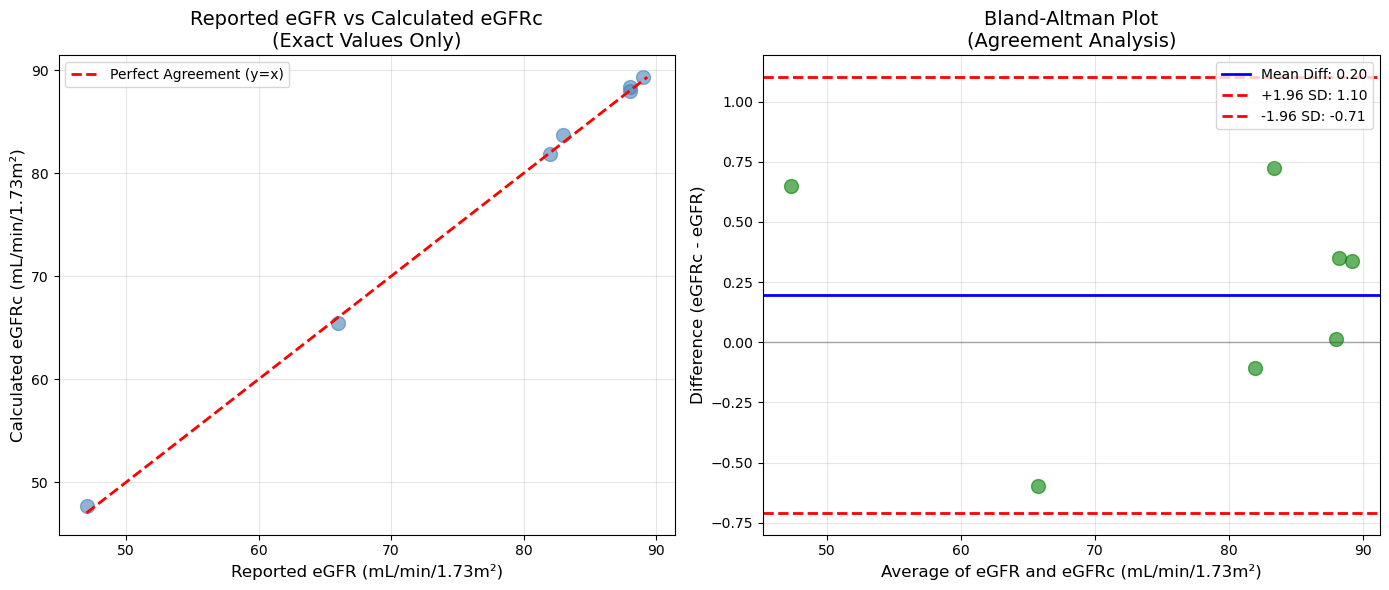


INTERPRETATION NOTES

1. Reported eGFR values with '>' (e.g., '>90') indicate values above that threshold
2. eGFRc is calculated using the CKD-EPI formula with serum creatinine and age
3. Differences may occur due to:
   - Different formulas used (reported vs calculated)
   - Rounding in reported values
   - Additional factors in clinical reporting (e.g., race, which we don't have)
4. The Bland-Altman plot shows agreement between methods
   - Points within ±1.96 SD indicate acceptable agreement



In [59]:
# Create a comparison dataframe
comparison_df = anon_seg_egfr_df[['record_id', 'current_age', 'serum_creatinine', 
                                   'egfr_value', 'egfrc']].copy()

print("="*80)
print("COMPARISON: Reported eGFR vs Calculated eGFRc")
print("="*80)

# Function to convert egfr_value to numeric for comparison
def parse_egfr_value(val):
    """Convert eGFR value to numeric. Returns lower bound for '>90' and '>60' etc."""
    if pd.isna(val):
        return None
    val_str = str(val).strip()
    # Handle compound values like '>90 | >90' - take the first value
    if '|' in val_str:
        val_str = val_str.split('|')[0].strip()
    if val_str.startswith('>'):
        # For '>90', return 90 as the minimum value
        return float(val_str[1:])
    elif val_str.startswith('<'):
        # For '<15', return 15 as the maximum value
        return float(val_str[1:])
    else:
        try:
            return float(val_str)
        except:
            return None

# Parse egfr_value to numeric
comparison_df['egfr_value_numeric'] = comparison_df['egfr_value'].apply(parse_egfr_value)

# Calculate difference (only for exact values, not '>90')
comparison_df['is_exact'] = ~comparison_df['egfr_value'].astype(str).str.contains('>', na=False)
comparison_df['difference'] = comparison_df.apply(
    lambda row: row['egfrc'] - row['egfr_value_numeric'] if row['is_exact'] else None, 
    axis=1
)

# Display the comparison
print("\nFull Comparison Table:")
print("-"*80)
display(comparison_df[['record_id', 'current_age', 'serum_creatinine', 
                       'egfr_value', 'egfrc', 'difference']])

# Statistics for records with exact eGFR values (not '>90')
exact_records = comparison_df[comparison_df['is_exact']].copy()

if len(exact_records) > 0:
    print("\n" + "="*80)
    print(f"STATISTICS FOR EXACT eGFR VALUES (n={len(exact_records)})")
    print("="*80)
    print(f"Mean difference (eGFRc - eGFR): {exact_records['difference'].mean():.2f} mL/min/1.73m²")
    print(f"Median difference: {exact_records['difference'].median():.2f} mL/min/1.73m²")
    print(f"Std Dev of difference: {exact_records['difference'].std():.2f} mL/min/1.73m²")
    print(f"Min difference: {exact_records['difference'].min():.2f} mL/min/1.73m²")
    print(f"Max difference: {exact_records['difference'].max():.2f} mL/min/1.73m²")
    
    # Correlation for exact values
    corr = exact_records[['egfr_value_numeric', 'egfrc']].corr().iloc[0, 1]
    print(f"\nCorrelation (exact values): {corr:.3f}")

# Count by eGFR category
print("\n" + "="*80)
print("DISTRIBUTION BY REPORTED eGFR VALUE")
print("="*80)
print(comparison_df['egfr_value'].value_counts().sort_index())

# Show records where eGFRc suggests different kidney function stage
print("\n" + "="*80)
print("RECORDS WHERE eGFRc < 90 BUT REPORTED eGFR IS '>90'")
print("="*80)
discrepancy = comparison_df[
    (comparison_df['egfr_value'] == '>90') & 
    (comparison_df['egfrc'] < 90)
]
if len(discrepancy) > 0:
    print(f"Found {len(discrepancy)} records:")
    display(discrepancy[['record_id', 'current_age', 'serum_creatinine', 
                         'egfr_value', 'egfrc']])
else:
    print("No discrepancies found - all '>90' records have eGFRc ≥ 90")

# Visualization: Scatter plot for exact values
if len(exact_records) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Plot 1: Scatter plot with identity line
    axes[0].scatter(exact_records['egfr_value_numeric'], exact_records['egfrc'], 
                   s=100, alpha=0.6, color='steelblue')
    
    # Add identity line (y=x)
    min_val = min(exact_records['egfr_value_numeric'].min(), exact_records['egfrc'].min())
    max_val = max(exact_records['egfr_value_numeric'].max(), exact_records['egfrc'].max())
    axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, 
                label='Perfect Agreement (y=x)')
    
    axes[0].set_xlabel('Reported eGFR (mL/min/1.73m²)', fontsize=12)
    axes[0].set_ylabel('Calculated eGFRc (mL/min/1.73m²)', fontsize=12)
    axes[0].set_title('Reported eGFR vs Calculated eGFRc\n(Exact Values Only)', fontsize=14)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Bland-Altman plot (difference vs average)
    exact_records['average'] = (exact_records['egfr_value_numeric'] + exact_records['egfrc']) / 2
    mean_diff = exact_records['difference'].mean()
    std_diff = exact_records['difference'].std()
    
    axes[1].scatter(exact_records['average'], exact_records['difference'], 
                   s=100, alpha=0.6, color='green')
    axes[1].axhline(mean_diff, color='blue', linestyle='-', linewidth=2, 
                   label=f'Mean Diff: {mean_diff:.2f}')
    axes[1].axhline(mean_diff + 1.96*std_diff, color='red', linestyle='--', linewidth=2,
                   label=f'+1.96 SD: {mean_diff + 1.96*std_diff:.2f}')
    axes[1].axhline(mean_diff - 1.96*std_diff, color='red', linestyle='--', linewidth=2,
                   label=f'-1.96 SD: {mean_diff - 1.96*std_diff:.2f}')
    axes[1].axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.3)
    
    axes[1].set_xlabel('Average of eGFR and eGFRc (mL/min/1.73m²)', fontsize=12)
    axes[1].set_ylabel('Difference (eGFRc - eGFR)', fontsize=12)
    axes[1].set_title('Bland-Altman Plot\n(Agreement Analysis)', fontsize=14)
    axes[1].legend(loc='best')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("\nNo exact eGFR values available for visualization.")
    print("All records have categorical values like '>90'")

# Summary interpretation
print("\n" + "="*80)
print("INTERPRETATION NOTES")
print("="*80)
print("""
1. Reported eGFR values with '>' (e.g., '>90') indicate values above that threshold
2. eGFRc is calculated using the CKD-EPI formula with serum creatinine and age
3. Differences may occur due to:
   - Different formulas used (reported vs calculated)
   - Rounding in reported values
   - Additional factors in clinical reporting (e.g., race, which we don't have)
4. The Bland-Altman plot shows agreement between methods
   - Points within ±1.96 SD indicate acceptable agreement
""")

## vGFR I

In [74]:
record_data = anon_seg_egfr_df[anon_seg_egfr_df['record_id'] == int(case_test)]

record_data[[
      'record_id', 'current_age', 'scan_date', 'egfr_date',  'date_diff_days', 
       'serum_creatinine', 'egfr_value', 'egfrc',
      'arterial_left_kidney_artery', 'arterial_right_kidney_artery', 'arterial_left_kidney_vein', 'arterial_right_kidney_vein','vgfr_arterial_mean', 
      'venous_left_kidney_artery', 'venous_right_kidney_artery', 'venous_left_kidney_vein', 'venous_right_kidney_vein', 'vgfr_venous_mean', 
      'late_left_kidney_artery', 'late_right_kidney_artery', 'late_left_kidney_vein', 'late_right_kidney_vein', 'vgfr_late_mean'
      ]].head(3)

,record_id,current_age,scan_date,egfr_date,date_diff_days,serum_creatinine,egfr_value,egfrc,arterial_left_kidney_artery,arterial_right_kidney_artery,arterial_left_kidney_vein,arterial_right_kidney_vein,vgfr_arterial_mean,venous_left_kidney_artery,venous_right_kidney_artery,venous_left_kidney_vein,venous_right_kidney_vein,vgfr_venous_mean,late_left_kidney_artery,late_right_kidney_artery,late_left_kidney_vein,late_right_kidney_vein,vgfr_late_mean
2,3,58,06-11-2024,01-11-2024,5,73.0,>90,97.193088,262,255,251,249,19.654243,134,132,137,138,-20.352782,61,58,61,57,5.172414


In [75]:
record_data[[
      'record_id', 'current_age', 'scan_date', 'egfr_date',  'date_diff_days', 
       'serum_creatinine', 'egfr_value', 'egfrc',
      'vgfr_arterial_mean', 
      'vgfr_venous_mean', 
      'vgfr_late_mean'
      ]].head(3)

,record_id,current_age,scan_date,egfr_date,date_diff_days,serum_creatinine,egfr_value,egfrc,vgfr_arterial_mean,vgfr_venous_mean,vgfr_late_mean
2,3,58,06-11-2024,01-11-2024,5,73.0,>90,97.193088,19.654243,-20.352782,5.172414


In [76]:
# Calculate statistics for each phase
print("vGFR STATISTICS BY PHASE")
print("="*80)

phases = ['arterial', 'venous', 'late']

df = anon_seg_egfr_df.copy()

for phase in phases:
    print(f"\n{phase.upper()} PHASE:")
    print("-"*80)
    
    left_col = f'vgfr_{phase}_left'
    right_col = f'vgfr_{phase}_right'
    mean_col = f'vgfr_{phase}_mean'
    
    print(f"Left Kidney:")
    print(f"  Mean: {df[left_col].mean():.2f} mL/min")
    print(f"  Median: {df[left_col].median():.2f} mL/min")
    print(f"  Range: [{df[left_col].min():.2f}, {df[left_col].max():.2f}]")
    
    print(f"\nRight Kidney:")
    print(f"  Mean: {df[right_col].mean():.2f} mL/min")
    print(f"  Median: {df[right_col].median():.2f} mL/min")
    print(f"  Range: [{df[right_col].min():.2f}, {df[right_col].max():.2f}]")
    
    print(f"\nBoth Kidneys (Mean):")
    print(f"  Mean: {df[mean_col].mean():.2f} mL/min")
    print(f"  Median: {df[mean_col].median():.2f} mL/min")
    print(f"  Range: [{df[mean_col].min():.2f}, {df[mean_col].max():.2f}]")

vGFR STATISTICS BY PHASE

ARTERIAL PHASE:
--------------------------------------------------------------------------------
Left Kidney:
  Mean: 200.88 mL/min
  Median: 203.42 mL/min
  Range: [25.19, 373.70]

Right Kidney:
  Mean: 170.25 mL/min
  Median: 173.49 mL/min
  Range: [-39.65, 392.23]

Both Kidneys (Mean):
  Mean: 185.57 mL/min
  Median: 183.31 mL/min
  Range: [-6.07, 382.97]

VENOUS PHASE:
--------------------------------------------------------------------------------
Left Kidney:
  Mean: -14.06 mL/min
  Median: -9.38 mL/min
  Range: [-152.46, 156.10]

Right Kidney:
  Mean: -14.29 mL/min
  Median: 0.00 mL/min
  Range: [-164.06, 94.34]

Both Kidneys (Mean):
  Mean: -14.17 mL/min
  Median: -9.19 mL/min
  Range: [-158.26, 83.76]

LATE PHASE:
--------------------------------------------------------------------------------
Left Kidney:
  Mean: 3.50 mL/min
  Median: 0.00 mL/min
  Range: [-124.14, 101.69]

Right Kidney:
  Mean: 16.62 mL/min
  Median: 10.34 mL/min
  Range: [-79.41, 1

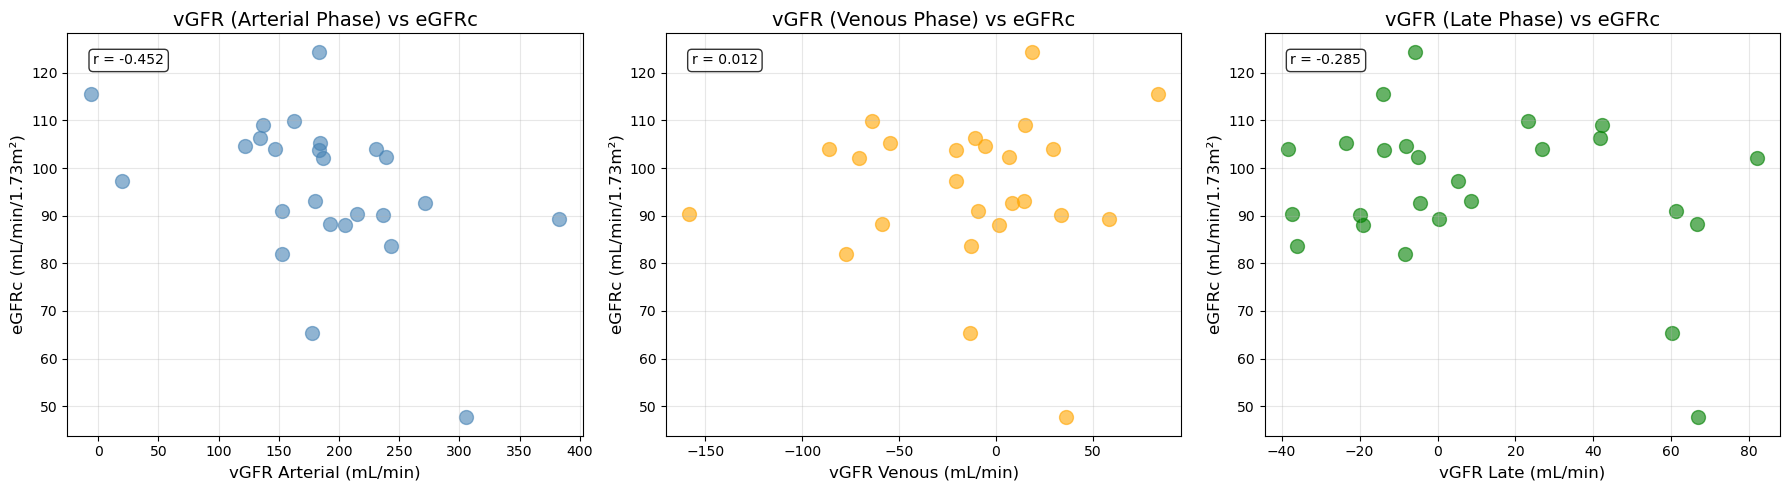

In [78]:
# Create comparison plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

phases = ['arterial', 'venous', 'late']
colors = ['steelblue', 'orange', 'green']

for idx, (phase, color) in enumerate(zip(phases, colors)):
    mean_col = f'vgfr_{phase}_mean'
    
    # Swapped: vGFR on x-axis, eGFRc on y-axis
    axes[idx].scatter(df[mean_col], df['egfrc'], alpha=0.6, s=100, color=color)
    axes[idx].set_xlabel(f'vGFR {phase.title()} (mL/min)', fontsize=12)
    axes[idx].set_ylabel('eGFRc (mL/min/1.73m²)', fontsize=12)
    axes[idx].set_title(f'vGFR ({phase.title()} Phase) vs eGFRc', fontsize=14)
    axes[idx].grid(True, alpha=0.3)
    
    # Calculate correlation
    corr = df[['egfrc', mean_col]].corr().iloc[0, 1]
    axes[idx].text(0.05, 0.95, f'r = {corr:.3f}', 
                   transform=axes[idx].transAxes, 
                   verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

In [79]:
print("EXTRACTION RATIO ANALYSIS")
print("="*80)

def calc_extraction_ratio(p_ra, p_rv):
    """Calculate extraction ratio E = (P_RA - P_RV) / P_RA"""
    if pd.isna(p_ra) or pd.isna(p_rv) or p_ra == 0:
        return None
    return (p_ra - p_rv) / p_ra

# Calculate extraction ratios
df['E_arterial_left'] = df.apply(lambda row: calc_extraction_ratio(
    row['arterial_left_kidney_artery'], row['arterial_left_kidney_vein']), axis=1)
df['E_arterial_right'] = df.apply(lambda row: calc_extraction_ratio(
    row['arterial_right_kidney_artery'], row['arterial_right_kidney_vein']), axis=1)

df['E_venous_left'] = df.apply(lambda row: calc_extraction_ratio(
    row['venous_left_kidney_artery'], row['venous_left_kidney_vein']), axis=1)
df['E_venous_right'] = df.apply(lambda row: calc_extraction_ratio(
    row['venous_right_kidney_artery'], row['venous_right_kidney_vein']), axis=1)

df['E_late_left'] = df.apply(lambda row: calc_extraction_ratio(
    row['late_left_kidney_artery'], row['late_left_kidney_vein']), axis=1)
df['E_late_right'] = df.apply(lambda row: calc_extraction_ratio(
    row['late_right_kidney_artery'], row['late_right_kidney_vein']), axis=1)

# Display statistics
print("\nExtraction Ratio Statistics:")
print("-"*80)

for phase in ['arterial', 'venous', 'late']:
    left_col = f'E_{phase}_left'
    right_col = f'E_{phase}_right'
    
    print(f"\n{phase.upper()} Phase:")
    print(f"  Left:  Mean = {df[left_col].mean():.3f}, Range = [{df[left_col].min():.3f}, {df[left_col].max():.3f}]")
    print(f"  Right: Mean = {df[right_col].mean():.3f}, Range = [{df[right_col].min():.3f}, {df[right_col].max():.3f}]")

# Note about negative values
print("\n" + "="*80)
print("NOTE: Negative extraction ratios occur when P_RV > P_RA")
print("This may indicate:")
print("  - Measurement artifacts")
print("  - Recirculation effects")
print("  - Phase-specific physiology")
print("  - Need for quality control filtering")

EXTRACTION RATIO ANALYSIS

Extraction Ratio Statistics:
--------------------------------------------------------------------------------

ARTERIAL Phase:
  Left:  Mean = 0.335, Range = [0.042, 0.623]
  Right: Mean = 0.284, Range = [-0.066, 0.654]

VENOUS Phase:
  Left:  Mean = -0.023, Range = [-0.254, 0.260]
  Right: Mean = -0.024, Range = [-0.273, 0.157]

LATE Phase:
  Left:  Mean = 0.006, Range = [-0.207, 0.169]
  Right: Mean = 0.028, Range = [-0.132, 0.237]

NOTE: Negative extraction ratios occur when P_RV > P_RA
This may indicate:
  - Measurement artifacts
  - Recirculation effects
  - Phase-specific physiology
  - Need for quality control filtering


C:\Users\FilipeFurlanBellotti\AppData\Local\Temp\ipykernel_22888\1673226290.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=vgfr_data_melted, x='Phase', y='vGFR', palette='Set2')


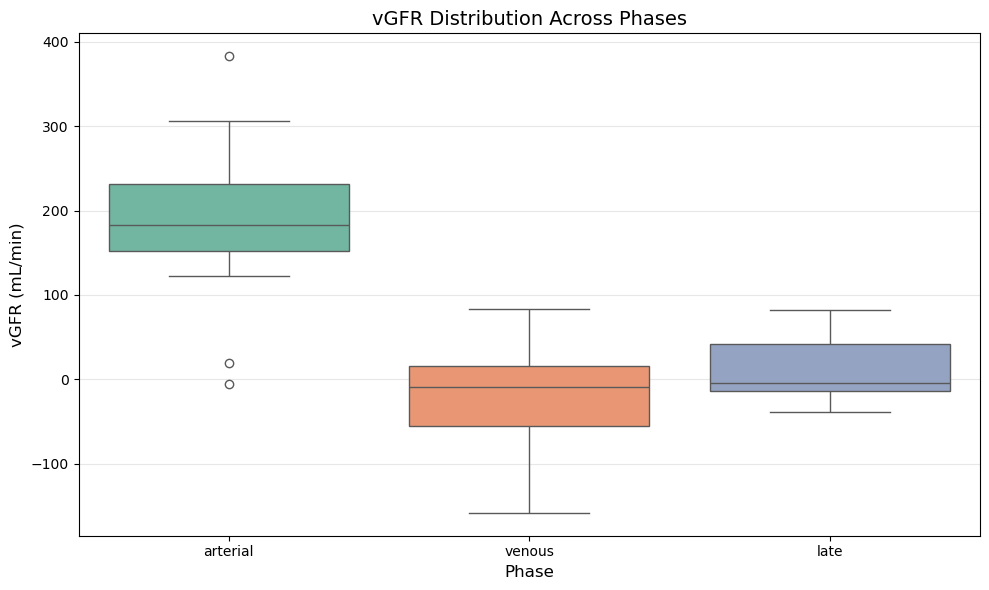


Phase Comparison:
          count        mean        std         min         25%         50%  \
Phase                                                                        
arterial   25.0  185.566730  79.193003   -6.073789  152.564489  183.308010   
late       25.0   10.060805  36.171818  -38.333333  -13.993453   -4.615385   
venous     25.0  -14.172261  52.079941 -158.260758  -54.802260   -9.191108   

                 75%         max  
Phase                             
arterial  230.900134  382.967716  
late       41.666667   81.881940  
venous     15.267968   83.763066  


In [82]:
# Compare vGFR across phases
import seaborn as sns

# Prepare data for visualization
vgfr_data = df[['record_id', 'vgfr_arterial_mean', 'vgfr_venous_mean', 'vgfr_late_mean']].copy()
vgfr_data_melted = vgfr_data.melt(id_vars='record_id', 
                                   var_name='Phase', 
                                   value_name='vGFR')
vgfr_data_melted['Phase'] = vgfr_data_melted['Phase'].str.replace('vgfr_', '').str.replace('_mean', '')

# Create box plot
plt.figure(figsize=(10, 6))
sns.boxplot(data=vgfr_data_melted, x='Phase', y='vGFR', palette='Set2')
plt.xlabel('Phase', fontsize=12)
plt.ylabel('vGFR (mL/min)', fontsize=12)
plt.title('vGFR Distribution Across Phases', fontsize=14)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Statistical comparison
print("\nPhase Comparison:")
print("="*80)
print(vgfr_data_melted.groupby('Phase')['vGFR'].describe())